## Hovmoller 

In [76]:
import xarray as xr
import matplotlib.pyplot as plt
from cmocean import cm # for oceanography-specific colormaps
from scipy.io import loadmat
import numpy as np
import re
from xml.etree import ElementTree as ET
from matplotlib.path import Path
import pandas as pd
from matplotlib.colors import TwoSlopeNorm 
import matplotlib.colors as mcolors

### Functions

In [2]:
## kml to struct
def kml2struct(kml_file):
    """
    Import a .kml file as a list of dictionary structures with fields:
    Geometry, Name, Description, Lon, Lat, and BoundingBox.
    """
    # Read the KML file
    try:
        with open(kml_file, 'r', encoding='utf-8') as file:
            txt = file.read()
    except Exception as e:
        raise FileNotFoundError(f"Unable to open file {kml_file}: {e}")

    # Regular expression to match Placemark tags
    expr = r"<Placemark.+?>.+?</Placemark>"
    object_strings = re.findall(expr, txt, re.DOTALL)
    
    kml_struct = []

    for obj_str in object_strings:
        # Extract Name
        name_match = re.search(r"<name.*?>(.*?)</name>", obj_str, re.DOTALL)
        name = name_match.group(1).strip() if name_match else "undefined"

        # Extract Description
        desc_match = re.search(r"<description.*?>(.*?)</description>", obj_str, re.DOTALL)
        desc = desc_match.group(1).strip() if desc_match else ""

        # Determine Geometry Type
        geometry = ""
        if "<Point" in obj_str:
            geometry = "Point"
        elif "<LineString" in obj_str:
            geometry = "Line"
        elif "<Polygon" in obj_str:
            geometry = "Polygon"

        # Extract Coordinates
        coord_match = re.search(r"<coordinates.*?>(.*?)</coordinates>", obj_str, re.DOTALL)
        if not coord_match:
            continue  # Skip if no coordinates are found
        coord_str = coord_match.group(1).strip()
        coord_list = np.array([list(map(float, coord.split(','))) for coord in coord_str.split()])

        # Separate Lon, Lat, and handle Polygons
        lon = coord_list[:, 0]
        lat = coord_list[:, 1]
        if geometry == "Polygon":
            # Close the polygon by appending NaN
            lon = np.append(lon, np.nan)
            lat = np.append(lat, np.nan)

        # Create BoundingBox
        bounding_box = [[lon.min(), lat.min()], [lon.max(), lat.max()]]

        # Append to kml_struct
        kml_struct.append({
            "Geometry": geometry,
            "Name": name,
            "Description": desc,
            "Lon": lon,
            "Lat": lat,
            "BoundingBox": bounding_box
        })

    return kml_struct

In [3]:
# Load the KML file to get the polygon boundary
arch_kml_zona1 = "../../NHCS/hindcast/CROCO_BioEBUS_1990-2010/indices/BK150km.kml"
R1 = kml2struct(arch_kml_zona1)

# Extract Lon and Lat from the first polygon
lonb1 = R1[0]["Lon"]
latb1 = R1[0]["Lat"]

## Lon and lat for the whole dataset
lat = np.linspace(-33.0, 10.03286, 542).reshape(542, 1)  # Reshape to match eta_rho
lon = np.linspace(-118.9083, -68.90833, 602).reshape(1, 602)  # Reshape to match xi_rho

lats, lons = np.meshgrid(lat.flatten(), lon.flatten(), indexing="ij")

LON=lons
LAT=lats
# Create a path from the polygon coordinates
polygon = Path(np.column_stack((lonb1, latb1)))

# Flatten the LON and LAT to create coordinate pairs
lonlat_points = np.column_stack((LON.ravel(), LAT.ravel()))

# Check which points are inside the polygon
mask = polygon.contains_points(lonlat_points).reshape(LON.shape)

# Convert the mask to NaN for the outshore region
inshore_mask = np.where(mask, 1, np.nan)

In [4]:
Puertos = {
    "Pisco":  [-13.69388889,  -76.22416667],
    "Callao":   [-12.0575,  -77.15305556],
    "Chimbote": [-9.076666667,  -78.61472222],
    "Paita":    [-5.078055556,  -81.10638889],
    }

In [5]:
##Normalize
def normalize(data):
    return (data - data.min()) / (data.max() - data.min())

## Dataset

In [6]:
ds = xr.open_dataset('../../NHCS/hincast_1980-2015/croco_avg_Y1980M01.nc', 
                     chunks = {'time':1})
ds

<xarray.Dataset> Size: 891MB
Dimensions:     (xi_rho: 602, xi_u: 601, eta_rho: 542, eta_v: 541, s_rho: 32,
                 s_w: 33, time: 1, auxil: 4)
Coordinates: (12/13)
  * xi_rho      (xi_rho) float64 5kB 1.0 2.0 3.0 4.0 ... 599.0 600.0 601.0 602.0
  * xi_u        (xi_u) float64 5kB 1.5 2.5 3.5 4.5 ... 598.5 599.5 600.5 601.5
  * eta_rho     (eta_rho) float64 4kB 1.0 2.0 3.0 4.0 ... 540.0 541.0 542.0
  * eta_v       (eta_v) float64 4kB 1.5 2.5 3.5 4.5 ... 538.5 539.5 540.5 541.5
  * s_rho       (s_rho) float64 256B -0.9844 -0.9531 ... -0.04688 -0.01562
  * s_w         (s_w) float64 264B -1.0 -0.9688 -0.9375 ... -0.0625 -0.03125 0.0
    ...          ...
    lat_rho     (eta_rho, xi_rho) float64 3MB dask.array<chunksize=(542, 602), meta=np.ndarray>
    lon_u       (eta_rho, xi_u) float64 3MB dask.array<chunksize=(542, 601), meta=np.ndarray>
    lat_u       (eta_rho, xi_u) float64 3MB dask.array<chunksize=(542, 601), meta=np.ndarray>
    lon_v       (eta_v, xi_rho) float64 3MB dask.array<chunksize=(541, 602), meta=np.ndarray>
    lat_v       (eta_v, xi_rho) float64 3MB dask.array<chunksize=(541, 602), meta=np.ndarray>
  * time        (time) float32 4B 1.339e+06
Dimensions without coordinates: auxil
Data variables: (12/54)
    spherical   |S1 1B ...
    xl          float64 8B ...
    el          float64 8B ...
    Vtransform  float64 8B ...
    sc_r        (s_rho) float64 256B dask.array<chunksize=(32,), meta=np.ndarray>
    sc_w        (s_w) float64 264B dask.array<chunksize=(33,), meta=np.ndarray>
    ...          ...
    swflux      (time, eta_rho, xi_rho) float32 1MB dask.array<chunksize=(1, 542, 602), meta=np.ndarray>
    radsw       (time, eta_rho, xi_rho) float32 1MB dask.array<chunksize=(1, 542, 602), meta=np.ndarray>
    shflx_rlw   (time, eta_rho, xi_rho) float32 1MB dask.array<chunksize=(1, 542, 602), meta=np.ndarray>
    shflx_lat   (time, eta_rho, xi_rho) float32 1MB dask.array<chunksize=(1, 542, 602), meta=np.ndarray>
    shflx_sen   (time, eta_rho, xi_rho) float32 1MB dask.array<chunksize=(1, 542, 602), meta=np.ndarray>
    hel         (time, eta_rho, xi_rho) float32 1MB dask.array<chunksize=(1, 542, 602), meta=np.ndarray>
Attributes: (12/57)
    type:           ROMS restart file
    title:          Peru UW Interannual Run
    date:           
    rst_file:       croco_rst.nc
    his_file:       croco_his.nc
    avg_file:       croco_avg.nc
    ...             ...
    gamma2_expl:    Slipperiness parameter
    x_sponge:       0.0
    v_sponge:       0.0
    sponge_expl:    Sponge parameters : extent (m) & viscosity (m2.s-1)
    SRCS:           main.F step.F read_inp.F timers_roms.F init_scalars.F ini...
    CPP-options:    REGIONAL PERU_UW MPI OBC_WEST OBC_NORTH OBC_SOUTH BIOLOGY...

In [7]:
MLD = loadmat("../../NHCS/Processed/WMLD_MLD.mat")
print(MLD.keys())

dict_keys(['__header__', '__version__', '__globals__', 'MLD', 'WMLD'])


In [8]:
# ¨WMLD_MLD
SST = loadmat("../../NHCS/Processed/SST_SSH.mat")
print(SST.keys())

dict_keys(['__header__', '__version__', '__globals__', 'SSH', 'SST'])


In [9]:
# EKMAN_components

Curl = loadmat("../../NHCS/Processed/EKMAN_components.mat")
print(Curl.keys())

dict_keys(['__header__', '__version__', '__globals__', 'Curl', 'Divergence', 'Crosshore_wind', 'VTauy', 'EK_pump', 'UEK', 'VEK', 'LTM_ekpump'])


In [10]:
## mask
print(ds.mask_rho.shape)
mask_rho = ds.mask_rho.values 
mask_nan = np.where(mask_rho, 1, np.nan)
expanded_mask = np.tile(mask_nan[np.newaxis, :, :], (432, 1, 1))
print(expanded_mask.shape)
print(MLD['WMLD'].shape)

(542, 602)
(432, 542, 602)
(542, 602, 432)


In [11]:
time = pd.date_range(start="1980-01",end="2016-01",freq='M')

Strat_ds = xr.Dataset(
    data_vars={
        'MLD': (("time", "lat","lon"), MLD['MLD'].transpose(2, 1, 0)*expanded_mask),
        'WMLD': (("time", "lat","lon"), MLD['WMLD'].transpose(2, 0, 1)*expanded_mask),
        'Curl':(("time", "lat","lon"), Curl['Curl'].transpose(2, 1, 0)*-1),
        'Ekt':(("time", "lat","lon"), Curl['UEK'].transpose(2, 1, 0)*-1),
        'SST':(("time", "lat","lon"), SST['SST'].transpose(2, 1, 0)*expanded_mask),
        'SSH':(("time", "lat","lon"), SST['SSH'].transpose(2, 1, 0)*expanded_mask),
    },
    coords = {
        'lon':ds.lon_rho.compute().values[0,:],
        'lat':ds.lat_rho.compute().values[:,0],
        'time':time
}
)

Strat_ds['SSH'] = Strat_ds['SSH']*100 #cm
Strat_ds['Curl'] = Strat_ds['Curl']*86400 #day
Strat_ds['WMLD'] = Strat_ds['WMLD']*86400 #m/day
Strat_ds['Ekt'] = Strat_ds['Ekt']*86400 #m2/day

/tmp/ipykernel_2805859/590154343.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  time = pd.date_range(start="1980-01",end="2016-01",freq='M')


In [12]:
# Strat_ts = Strat_ds.sel(lat=slice(-16,0),lon=slice(-90,-74))
strat_mmean = Strat_ds.groupby('time.month').mean(dim='time')
strat_anomaly = Strat_ds.groupby('time.month') - strat_mmean

In [13]:
### dataset

strat_anomaly

<xarray.Dataset> Size: 7GB
Dimensions:  (lon: 602, lat: 542, time: 432)
Coordinates:
  * lon      (lon) float64 5kB -119.0 -118.9 -118.8 ... -69.03 -68.95 -68.87
  * lat      (lat) float64 4kB -33.0 -32.93 -32.86 -32.79 ... 9.869 9.951 10.03
  * time     (time) datetime64[ns] 3kB 1980-01-31 1980-02-29 ... 2015-12-31
    month    (time) int64 3kB 1 2 3 4 5 6 7 8 9 10 11 ... 3 4 5 6 7 8 9 10 11 12
Data variables:
    MLD      (time, lat, lon) float64 1GB -6.107 -6.107 -6.514 ... nan nan nan
    WMLD     (time, lat, lon) float64 1GB -1.013 -1.013 -1.277 ... nan nan nan
    Curl     (time, lat, lon) float64 1GB 0.006496 0.007581 0.008833 ... nan nan
    Ekt      (time, lat, lon) float64 1GB -4.012e+03 -4.357e+03 ... nan nan
    SST      (time, lat, lon) float64 1GB -0.2383 -0.2361 -0.2281 ... nan nan
    SSH      (time, lat, lon) float64 1GB -5.694 -5.694 -6.155 ... nan nan nan

In [14]:
equator = strat_anomaly.sel(lat=slice(-2,2),lon=slice(None,-78)).mean(dim='lat',skipna=True)
equator 

<xarray.Dataset> Size: 10MB
Dimensions:  (lon: 492, time: 432)
Coordinates:
  * lon      (lon) float64 4kB -119.0 -118.9 -118.8 ... -78.2 -78.12 -78.03
  * time     (time) datetime64[ns] 3kB 1980-01-31 1980-02-29 ... 2015-12-31
    month    (time) int64 3kB 1 2 3 4 5 6 7 8 9 10 11 ... 3 4 5 6 7 8 9 10 11 12
Data variables:
    MLD      (time, lon) float64 2MB 7.999 7.999 10.12 11.11 ... nan nan nan nan
    WMLD     (time, lon) float64 2MB 0.7536 0.7536 3.417 2.247 ... nan nan nan
    Curl     (time, lon) float64 2MB 2.116e-05 0.0006551 0.000896 ... nan nan
    Ekt      (time, lon) float64 2MB -1.968e+06 -1.22e+06 -1.35e+06 ... nan nan
    SST      (time, lon) float64 2MB 0.8674 0.6355 0.6461 0.6216 ... nan nan nan
    SSH      (time, lon) float64 2MB 5.594 5.594 5.546 5.502 ... nan nan nan nan

In [15]:
# * inshore_mask
# Strat_ds.sel(lat=slice(-16,0),lon=slice(,-74))
# ,lon=slice(-90,-78))
in_band = strat_anomaly*inshore_mask
band = in_band.sel(lat=slice(-16,0)).mean(dim='lon',skipna=True)
band

<xarray.Dataset> Size: 4MB
Dimensions:  (lat: 194, time: 432)
Coordinates:
  * lat      (lat) float64 2kB -15.95 -15.87 -15.79 ... -0.2494 -0.1661 -0.08278
  * time     (time) datetime64[ns] 3kB 1980-01-31 1980-02-29 ... 2015-12-31
    month    (time) int64 3kB 1 2 3 4 5 6 7 8 9 10 11 ... 3 4 5 6 7 8 9 10 11 12
Data variables:
    MLD      (time, lat) float64 670kB 2.397 2.773 3.2 ... -0.08167 -0.03037
    WMLD     (time, lat) float64 670kB 0.1423 0.12 -0.2658 ... 0.9723 1.06
    Curl     (time, lat) float64 670kB -0.003659 -0.002818 ... -0.004364
    Ekt      (time, lat) float64 670kB -3.736e+03 -4.009e+03 ... 1.344e+06
    SST      (time, lat) float64 670kB -0.2819 -0.3396 -0.4034 ... 1.723 1.72
    SSH      (time, lat) float64 670kB 0.9457 0.7811 0.636 ... 10.29 10.33 10.34

Text(0.5, 1.0, 'Band 150km')

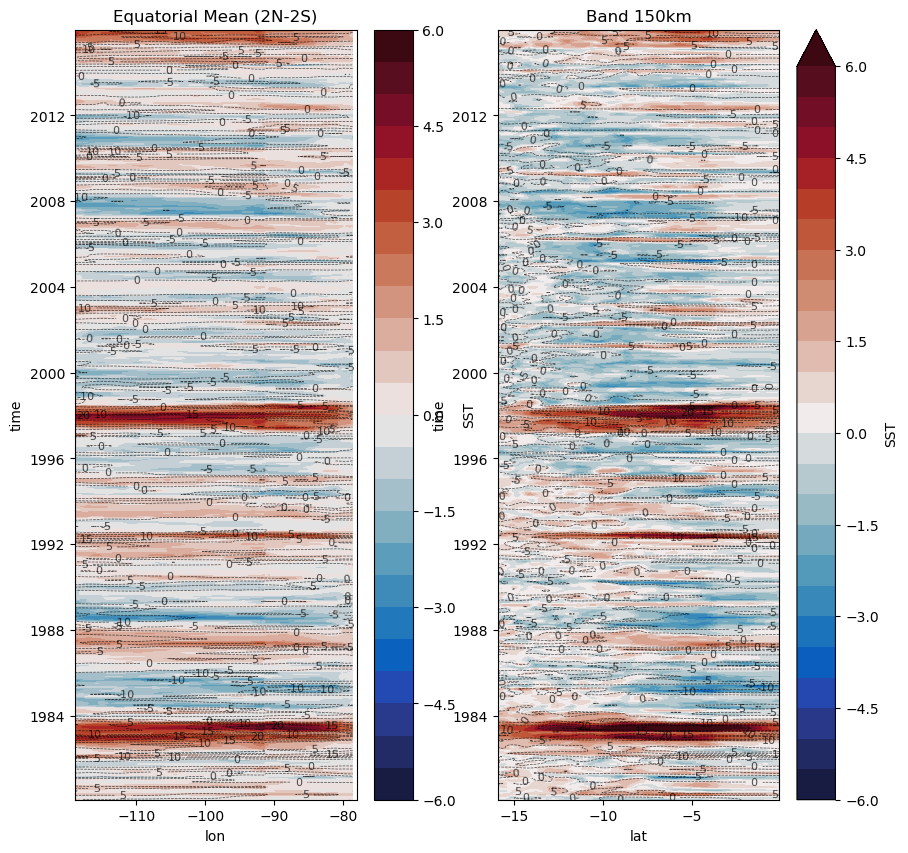

In [16]:
norm = TwoSlopeNorm(vmin=-6, vcenter=0, vmax=6)
levels=np.arange(-6,6+0.5,0.5)

norm_ssh = TwoSlopeNorm(vmin=-25, vcenter=0, vmax=25)
levels_ssh = np.arange(-25, 25, 5)

fig,ax = plt.subplots(1,2,figsize=(10,10))

#%-------- Equatorial strip
cf=equator.SST.plot.contourf(y="time",x='lon',vmin=-6, vmax=6,cmap = cm.balance,norm=norm,levels=levels,ax=ax[0])
cc=equator.SSH.plot.contour(y="time",x='lon',vmin=-25, vmax=25,colors='black',norm=norm_ssh,
                            levels=levels_ssh,linestyles='--', alpha=0.7,linewidths=0.5,ax=ax[0])
ax[0].clabel(cc, inline=True, fontsize=8, fmt="%.f")
ax[0].set_title('Equatorial Mean (2N-2S)')

#%-------- band strip 
cf=band.SST.plot.contourf(y="time",x='lat',vmin=-6, vmax=6,cmap = cm.balance,norm=norm,levels=levels,ax=ax[1])
cc=band.SSH.plot.contour(y="time",x='lat',vmin=-25, vmax=25,colors='black',norm=norm_ssh,
                            levels=levels_ssh,linestyles='--', alpha=0.7,linewidths=0.5,ax=ax[1])
ax[1].clabel(cc, inline=True, fontsize=8, fmt="%.f")
ax[1].set_title('Band 150km')




## ENSO events

### NINO 1982-1984

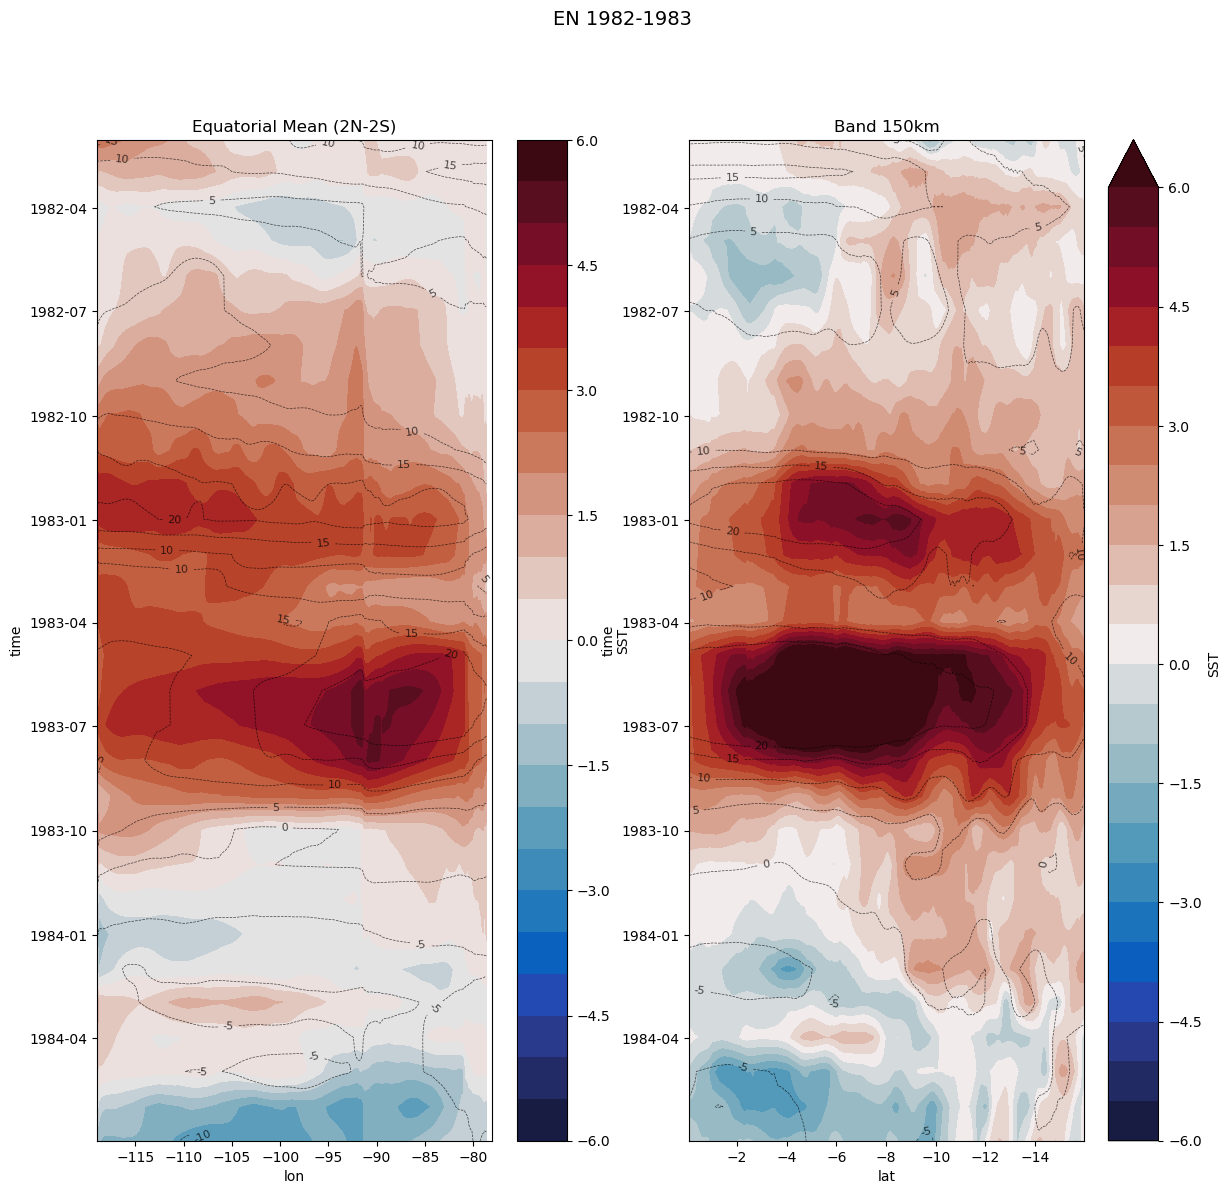

In [80]:
# slice("1982-01","1984-06")

fig,ax = plt.subplots(1,2,figsize=(14,13))

#%-------- Equatorial strip
cf=equator.sel(time=slice("1982-01","1984-06")).SST.plot.contourf(y="time",x='lon',vmin=-6, vmax=6,cmap = cm.balance,
                                                                 norm=norm,levels=levels,ax=ax[0])
cc=equator.sel(time=slice("1982-01","1984-06")).SSH.plot.contour(y="time",x='lon',vmin=-25, vmax=25,colors='black',norm=norm_ssh,
                            levels=levels_ssh,linestyles='--', alpha=0.7,linewidths=0.5,ax=ax[0])
ax[0].clabel(cc, inline=True, fontsize=8, fmt="%.f")
ax[0].set_title('Equatorial Mean (2N-2S)')
ax[0].invert_yaxis()

#%-------- band strip 
cf=band.sel(time=slice("1982-01","1984-06")).SST.plot.contourf(y="time",x='lat',vmin=-6, vmax=6,cmap = cm.balance,norm=norm,levels=levels,ax=ax[1])
cc=band.sel(time=slice("1982-01","1984-06")).SSH.plot.contour(y="time",x='lat',vmin=-25, vmax=25,colors='black',norm=norm_ssh,
                            levels=levels_ssh,linestyles='--', alpha=0.7,linewidths=0.5,ax=ax[1])
ax[1].clabel(cc, inline=True, fontsize=8, fmt="%.f")
ax[1].set_title('Band 150km')
ax[1].invert_yaxis()
ax[1].invert_xaxis()

plt.suptitle("EN 1982-1983", fontsize=14)

# plt.savefig('Figures/EN82_83_hovmoller'+'.png', format='png', dpi=300, transparent=False, bbox_inches='tight')


### NINO 1997-98

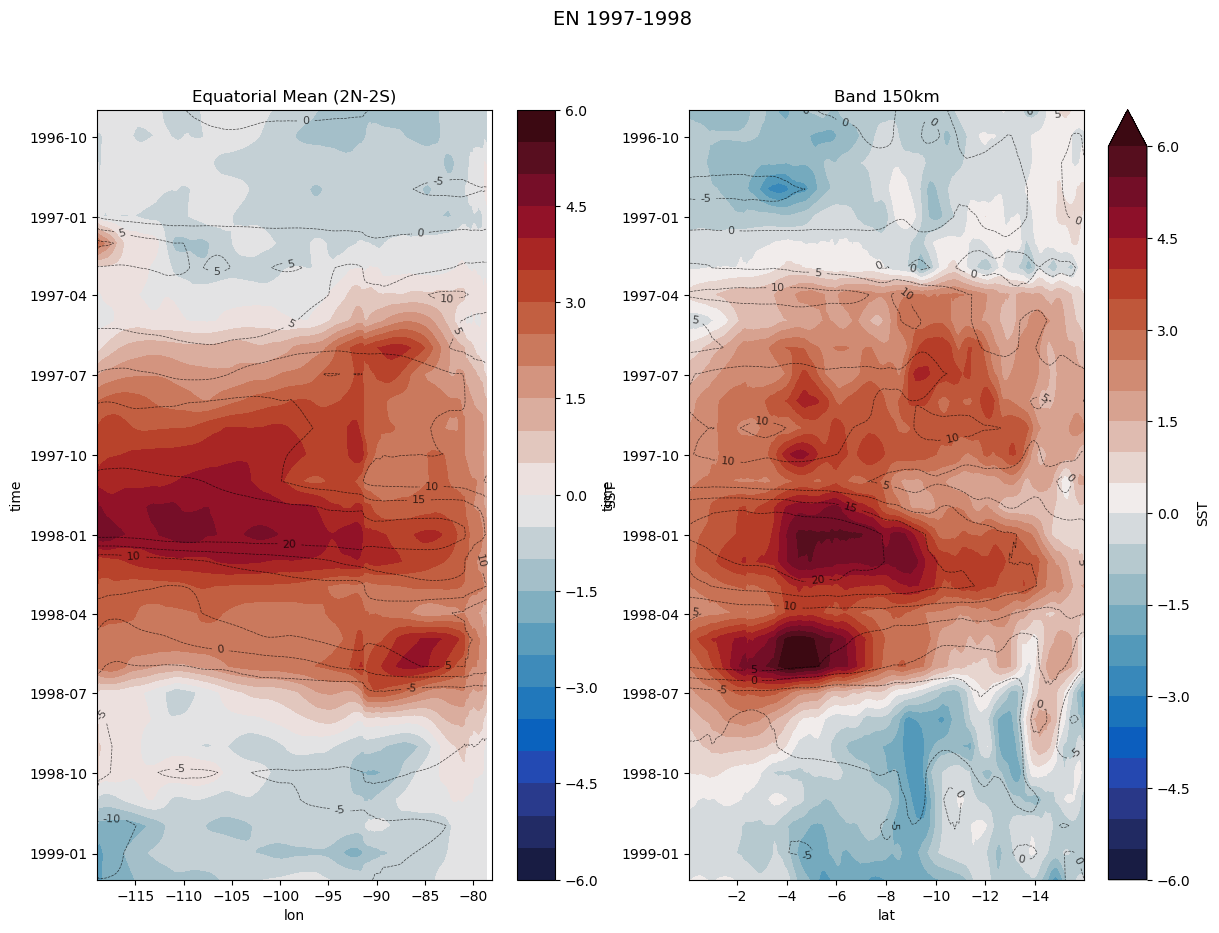

In [81]:
fig,ax = plt.subplots(1,2,figsize=(14,10))

#%-------- Equatorial strip
cf=equator.sel(time=slice("1996-08","1999-01")).SST.plot.contourf(y="time",x='lon',vmin=-6, vmax=6,cmap = cm.balance,
                                                                 norm=norm,levels=levels,ax=ax[0])
cc=equator.sel(time=slice("1996-08","1999-01")).SSH.plot.contour(y="time",x='lon',vmin=-25, vmax=25,colors='black',norm=norm_ssh,
                            levels=levels_ssh,linestyles='--', alpha=0.7,linewidths=0.5,ax=ax[0])
ax[0].clabel(cc, inline=True, fontsize=8, fmt="%.f")
ax[0].set_title('Equatorial Mean (2N-2S)')
ax[0].invert_yaxis()

#%-------- band strip 
cf=band.sel(time=slice("1996-08","1999-01")).SST.plot.contourf(y="time",x='lat',vmin=-6, vmax=6,cmap = cm.balance,norm=norm,levels=levels,ax=ax[1])
cc=band.sel(time=slice("1996-08","1999-01")).SSH.plot.contour(y="time",x='lat',vmin=-25, vmax=25,colors='black',norm=norm_ssh,
                            levels=levels_ssh,linestyles='--', alpha=0.7,linewidths=0.5,ax=ax[1])
ax[1].clabel(cc, inline=True, fontsize=8, fmt="%.f")
ax[1].set_title('Band 150km')
ax[1].invert_yaxis()
ax[1].invert_xaxis()

plt.suptitle("EN 1997-1998", fontsize=14)

# plt.savefig('Figures/EN97_98_hovmoller'+'.png', format='png', dpi=300, transparent=False, bbox_inches='tight')


### WMLD vs MLD during ENSO in the Upwelling region

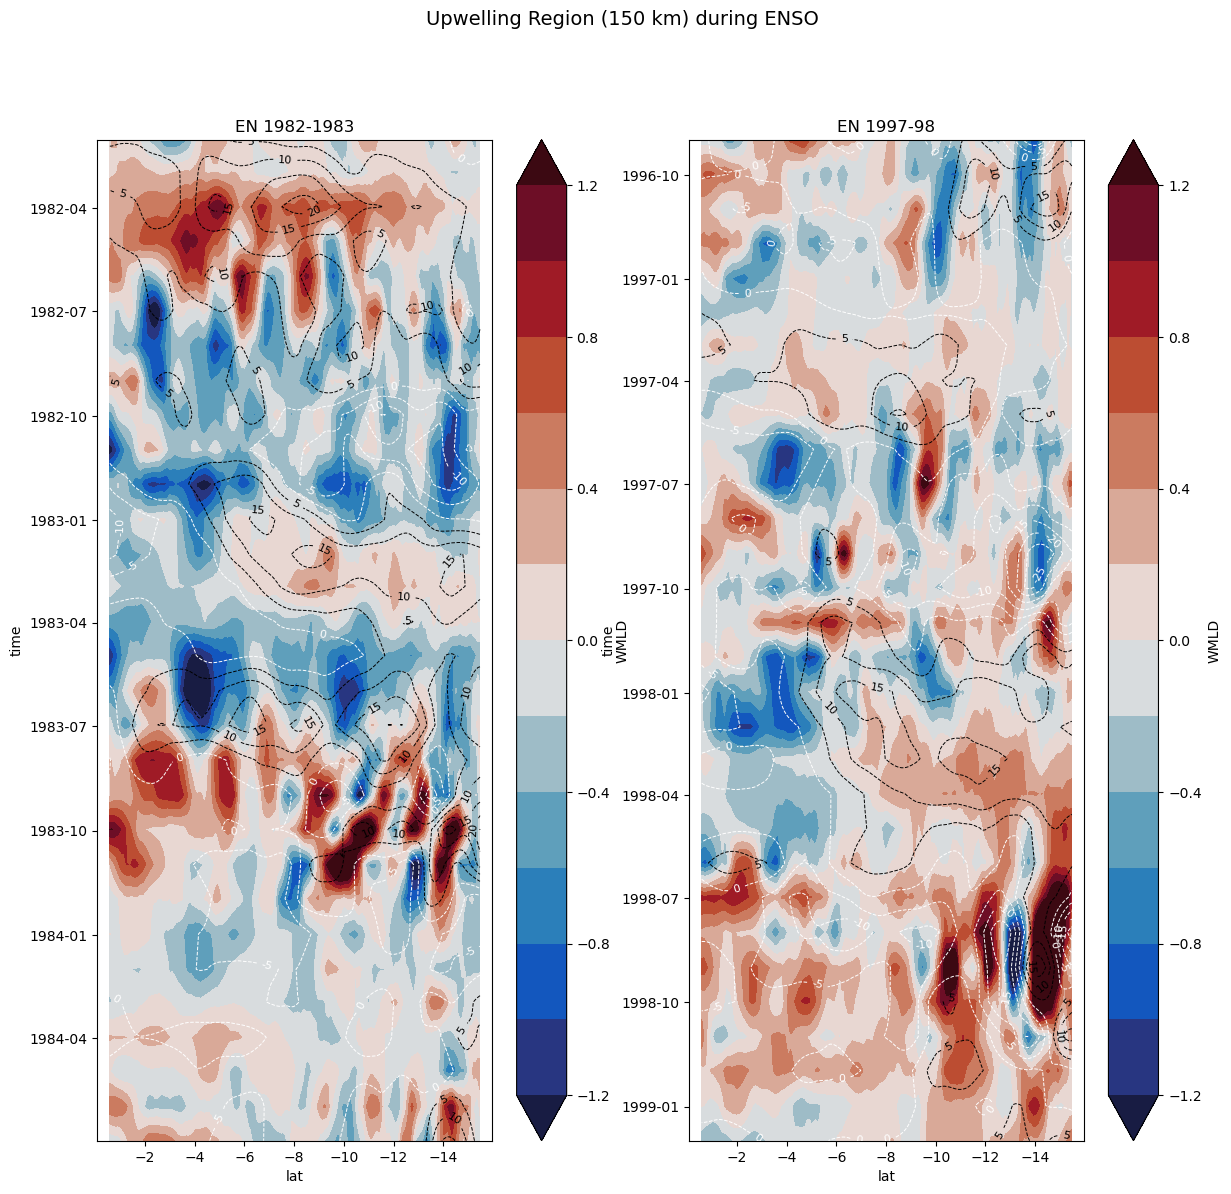

In [82]:
## MLD anomaly vs WMLD anomaly
norm_MLD = TwoSlopeNorm(vmin=-30, vcenter=0, vmax=30)
levels_MLD = np.arange(-30, 30+5, 5)

norm_WMLD = TwoSlopeNorm(vmin=-1.2, vcenter=0, vmax=1.2)
levels_WMLD = np.arange(-1.2, 1.2+0.2, 0.2)

colors = ['white' if x < 0 else 'black' for x in levels_WMLD]
cmap_div = mcolors.ListedColormap(colors)

fig,ax = plt.subplots(1,2,figsize=(14,13))
#%----- Equator
# cc=equator.rolling(lon=13,center=True).mean().sel(time=slice("1982-01","1984-06")).WMLD.plot.contourf(y='time',x='lon',vmin=-1.2, vmax=1.2,cmap = cm.balance,
#                                                               norm=norm_WMLD, levels=levels_WMLD,ax=ax[0])

# cf=equator.sel(time=slice("1982-01","1984-06")).MLD.plot.contour(y="time",x='lon',vmin=-30, vmax=30,colors='Black',
#                                                                  norm=norm_MLD,levels=levels_MLD, linestyles='--', 
#                                                                alpha=1,linewidths=0.7,ax=ax[0])

# ax[0].clabel(cf, inline=True, fontsize=8, fmt="%.f")

# ax[0].invert_yaxis()

#%--------- EN 1982-1983

cf=band.rolling(lat=13,center=True).mean().sel(time=slice("1982-01","1984-06")).WMLD.plot.contourf(y='time',x='lat',vmin=-1.2, vmax=1.2,cmap = cm.balance,
                                                              norm=norm_WMLD, levels=levels_WMLD,ax=ax[0])

cc=band.rolling(lat=13,center=True).mean().sel(time=slice("1982-01","1984-06")).MLD.plot.contour(y="time",x='lat',vmin=-30, vmax=30,cmap=cmap_div,
                                                                 norm=norm_MLD,levels=levels_MLD, linestyles='--', 
                                                               alpha=1,linewidths=0.7,ax=ax[0])
ax[0].clabel(cc, inline=True, fontsize=8, fmt="%.f")
ax[0].set_title('EN 1982-1983')
ax[0].invert_yaxis()
ax[0].invert_xaxis()

#%--------- EN 1997-1998

cf=band.rolling(lat=13,center=True).mean().sel(time=slice("1996-08","1999-01")).WMLD.plot.contourf(y='time',x='lat',vmin=-1.2, vmax=1.2,cmap = cm.balance,
                                                              norm=norm_WMLD, levels=levels_WMLD,ax=ax[1])

cc=band.rolling(lat=13,center=True).mean().sel(time=slice("1996-08","1999-01")).MLD.plot.contour(y="time",x='lat',vmin=-30, vmax=30,cmap=cmap_div,
                                                                 norm=norm_MLD,levels=levels_MLD, linestyles='--', 
                                                               alpha=1,linewidths=0.7,ax=ax[1])
ax[1].clabel(cc, inline=True, fontsize=8, fmt="%.f")
ax[1].set_title('EN 1997-98')
ax[1].invert_yaxis()
ax[1].invert_xaxis()

plt.suptitle("Upwelling Region (150 km) during ENSO", fontsize=14)

# plt.savefig('Figures/UP_Region_hovmoller_ENSO'+'.png', format='png', dpi=300, transparent=False, bbox_inches='tight')
